In [211]:
################################################################################
# Author 1:      Lukas Umfahrer
# MatNr 1:       12337160
# Author 2:      Firstname Lastname
# MatNr 2:       01234567
# Author 3:      Firstname Lastname
# MatNr 3:       01234567
# File:          assignment2.ipynb
# Description: ... short description of the file ...
# Comments:    ... comments for the tutors ...
#              ... can be multiline ...
################################################################################


<center>
    <h1>Assignment 2</h1>
</center>

#### Imports

In [212]:
import pandas as pa
import matplotlib.pyplot as plt
import plotly as pl
import numpy as np
import pycountry as py
import pycountry_convert as pyco

## Part 1: Data Analysis & Visualization Code - Required Plots

### Line plots: Visualize data over time (4P)

In [213]:
def plot_alcohol_consumption(dataset: str, 
                             plot_title: str, 
                             x_label: str, 
                             y_label: str) -> None:
      
    figure, axis = plt.subplots(figsize=(10,7))

    #only using alcohol consumption data
    data_alc = dataset[dataset["MEASURE"]=="AC"]

    # filtering data from AUT, DEU, USA and CAN
    data_aut = data_alc[data_alc["REF_AREA"]=="AUT"]   
    data_deu = data_alc[data_alc["REF_AREA"]=="DEU"]   
    data_usa = data_alc[data_alc["REF_AREA"]=="USA"]   
    data_can = data_alc[data_alc["REF_AREA"]=="CAN"]


    # calculating mean per year
    data_aut_mean = data_aut.groupby("TIME_PERIOD")["OBS_VALUE"].mean()     
    data_deu_mean = data_deu.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 
    data_usa_mean = data_usa.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 
    data_can_mean = data_can.groupby("TIME_PERIOD")["OBS_VALUE"].mean() 

    # AUT plot
    ys_aut= data_aut_mean.values   # value
    xs_aut = data_aut_mean.index    # year

    axis.plot(xs_aut, ys_aut,
            marker="o",
            markersize="3",
            markeredgecolor="blue",
            label="AUT")
    
    # DEU plot
    ys_deu= data_deu_mean.values   # value
    xs_deu = data_deu_mean.index    # year

    axis.plot(xs_deu, ys_deu,
            marker="o",
            markersize="3",
            markeredgecolor="orange",
            label="DEU")
    
    # USA plot
    ys_usa = data_usa_mean.values   # value
    xs_usa = data_usa_mean.index    # year

    axis.plot(xs_usa, ys_usa,
            marker="o",
            markersize="3",
            markeredgecolor="green",
            label="USA")
    
    # CAN plot
    ys_can= data_can_mean.values   # value
    xs_can = data_can_mean.index    # year

    axis.plot(xs_can, ys_can,
            marker="o",
            markersize="3",
            markeredgecolor="red",
            label="CAN")

    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    plt.title(plot_title)
    plt.grid(True)


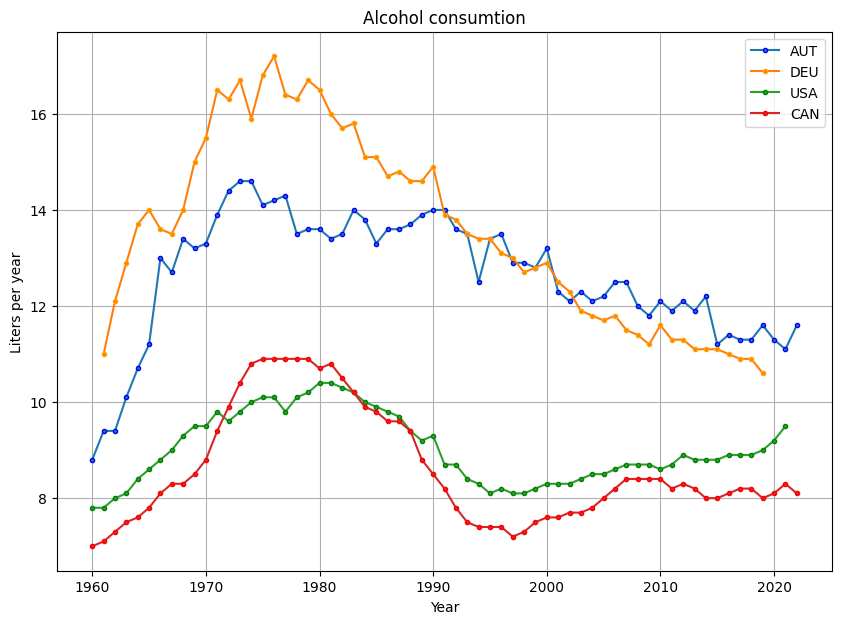

In [214]:
data = pa.read_csv("OECD.ELS.HD,DSD_HEALTH_LVNG@DF_HEALTH_LVNG,+all.csv", delimiter = ",")   # reading data

plot_alcohol_consumption(data,
                'Alcohol consumtion',
                'Year',
                'Liters per year') 

### Bar charts: Compare data from different countries (4P)

In [215]:
data = pa.read_csv("OECD.ELS.HD,DSD_HEALTH_LVNG@DF_HEALTH_LVNG,+all.csv", delimiter = ",")   # Daten einlesen
data

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Unnamed: 5,FREQ,Unnamed: 7,MEASURE,Unnamed: 9,...,TIME_PERIOD,Unnamed: 19,OBS_VALUE,Unnamed: 21,OBS_STATUS,Unnamed: 23,UNIT_MULT,Unnamed: 25,DECIMALS,Unnamed: 27
0,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,USA,NaN,A,NaN,FTS,NaN,...,1961,NaN,110.2,NaN,A,NaN,0,NaN,NaN,NaN
1,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,USA,NaN,A,NaN,FTS,NaN,...,1962,NaN,109.1,NaN,A,NaN,0,NaN,NaN,NaN
2,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,USA,NaN,A,NaN,FTS,NaN,...,1963,NaN,110.7,NaN,A,NaN,0,NaN,NaN,NaN
3,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,USA,NaN,A,NaN,FTS,NaN,...,1964,NaN,114.2,NaN,A,NaN,0,NaN,NaN,NaN
4,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,USA,NaN,A,NaN,FTS,NaN,...,1965,NaN,113.0,NaN,A,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33528,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,BGR,NaN,A,NaN,SP_OVRGHT,NaN,...,2014,NaN,46.7,NaN,A,NaN,0,NaN,NaN,NaN
33529,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,BGR,NaN,A,NaN,SP_OVRGHT,NaN,...,2019,NaN,48.8,NaN,A,NaN,0,NaN,NaN,NaN
33530,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,BGR,NaN,A,NaN,SP_OBS,NaN,...,2008,NaN,11.5,NaN,A,NaN,0,NaN,NaN,NaN
33531,DATAFLOW,OECD.ELS.HD:DSD_HEALTH_LVNG@DF_HEALTH_LVNG(1.0),NaN,I,BGR,NaN,A,NaN,SP_OBS,NaN,...,2014,NaN,14.8,NaN,A,NaN,0,NaN,NaN,NaN


Text(0, 0.5, 'Mean of the Obesityvalues')

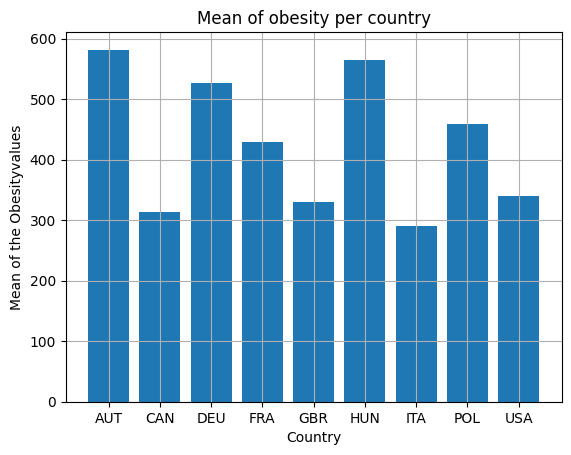

In [216]:
figure, axis = plt.subplots()

countrys_data = data[data["REF_AREA"].isin(["AUT", "DEU", "ITA", "USA", "CAN", "POL", "HUN", "FRA", "GBR"])]    # Daten von den gewollten Ländern

mean_per_country = countrys_data.groupby("REF_AREA")["OBS_VALUE"].mean()    # Durchschnitt der einzelnen Länder berechnen

ys = mean_per_country.values    # Werte
xs = mean_per_country.index     # Länder

plt.bar(xs, ys)

plt.title("Mean of obesity per country")
plt.grid(True)
axis.set_xlabel("Country")
axis.set_ylabel("Mean of the Obesityvalues")

### Scatter plots: Visualize the relationship between different variables (7P)